In [ ]:
%pip install puremacro


# Optimal monetary policy: a replication of Clarida, Galí and Gertler (1999)

**How much better can a central bank that commits stabilize inflation and the output gap than one that re-optimizes every period, and do puremacro's policy solvers reproduce the textbook answers exactly?**

Clarida, Galí and Gertler (1999), "The Science of Monetary Policy: A New Keynesian Perspective", *Journal of Economic Literature* 37(4), 1661-1707, derive optimal policy in the canonical New Keynesian model in closed form. Closed forms make a strict replication target: every number below is compared with a formula, not with an earlier puremacro run. No data are used, and the calibration is illustrative.

| Replication card | |
|---|---|
| Results replicated | Optimal discretion, commitment within a simple rule, and timeless-perspective commitment |
| Oracle | The paper's closed forms, plus the closed-form commitment path derived in Galí (2015, ch. 5) |
| Data | None; an illustrative quarterly calibration, then 25 random calibrations |
| Solvers tested | `discretionary_policy` (Dennis 2007 iteration), `lq_commitment`, `ramsey_model` (symbolic first-order conditions) and `osr` |
| Acceptance | Absolute error below 1e-9 for one-standard-deviation shocks; relative error below 1e-6 where a derivative-free search is involved |
| Verdict | Printed by the scorecard at the end, from the computed errors |

## The method in math

The output gap $x_t$ and inflation $\pi_t$ follow an IS curve and a Phillips curve with demand and cost-push shocks,
$$x_t=E_t x_{t+1}-\varphi\,(i_t-E_t\pi_{t+1})+g_t,\qquad \pi_t=\lambda x_t+\beta E_t\pi_{t+1}+u_t,$$
where $g_t=\mu g_{t-1}+\hat g_t$ and $u_t=\rho u_{t-1}+\hat u_t$. The central bank minimizes $E_t\sum_{j\ge 0}\beta^j(\alpha x_{t+j}^2+\pi_{t+j}^2)$. The results to reproduce are:

- **Discretion.** $x_t=-\frac{\lambda}{\alpha}\pi_t$, hence $\pi_t=\alpha q\,u_t$ and $x_t=-\lambda q\,u_t$ with $q=1/[\lambda^2+\alpha(1-\beta\rho)]$. The implied rule is $i_t=\gamma_\pi E_t\pi_{t+1}+g_t/\varphi$ with $\gamma_\pi=1+\frac{(1-\rho)\lambda}{\rho\varphi\alpha}>1$.
- **Commitment within the rule $x_t=-\omega u_t$.** $\omega^c=\lambda/[\lambda^2+\alpha(1-\beta\rho)^2]$, the discretionary policy of a central banker whose output weight is $\alpha(1-\beta\rho)<\alpha$.
- **Timeless-perspective commitment.** $\pi_t=-\frac{\alpha}{\lambda}(x_t-x_{t-1})$, so $x_t=\delta x_{t-1}-\frac{\lambda\delta}{\alpha(1-\delta\beta\rho)}u_t$ with $\delta=\frac{1-\sqrt{1-4\beta a^2}}{2a\beta}$ and $a=\frac{\alpha}{\alpha(1+\beta)+\lambda^2}$.

## Intuition

**Intuition.** A central bank acting under discretion takes expected inflation as given, so it can only trade today's output gap against today's inflation: it leans against the wind in the proportion $\lambda/\alpha$. A central bank that commits can also promise future policy. Promising a negative output gap later lowers expected inflation now, which improves today's trade-off. Within a simple rule the promise works through the persistence $\rho$ of the cost-push shock, and it is equivalent to appointing a more inflation-averse, "conservative" central banker in the sense of Rogoff (1985). Timeless commitment makes policy history dependent: the output gap stays negative after the shock has faded, and the price level returns to its starting point. Demand shocks involve no trade-off in this model, so every regime offsets them completely through the interest rate.

## Worked code

The model is written as Dynare-style text and closed with a placeholder Taylor rule, which each policy solver removes and replaces with its own optimal policy. Every shock has a standard deviation of one, so responses are in units of the shock and losses in units of its variance.

In [1]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo = Path.cwd() if (Path.cwd() / "puremacro").is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo))
sys.path.insert(0, str(repo / "notebooks"))
import _nbstyle
_nbstyle.apply_style()
from puremacro.dsge import build_dynare, discretionary_policy, osr, ramsey_model

# Illustrative quarterly calibration. The CGG results are closed forms, so the checks
# do not depend on these values; section 5 repeats them at random calibrations.
CALIB = {"beta": 0.99, "phi": 1.0, "lam": 0.1, "alpha": 0.25, "rho": 0.5, "mu": 0.8}
TOL = 1e-9   # absolute tolerance for one-standard-deviation shocks
H = 40       # impulse-response horizon in quarters


def cgg_model(params, rule="i = phi_pi*pi + phi_x*x;"):
    """The CGG (1999) economy; `rule` closes it for the private sector."""
    values = {"phi_pi": 1.5, "phi_x": 0.5, **params}
    text = ("var x pi i g u;\nvarexo eps_g eps_u;\n"
            f"parameters {' '.join(values)};\n"
            + "".join(f"{k} = {float(v)!r};\n" for k, v in values.items())
            + "model;\n"
            "x = x(+1) - phi*(i - pi(+1)) + g;\n"   # IS curve
            "pi = lam*x + beta*pi(+1) + u;\n"       # Phillips curve
            f"{rule}\n"
            "g = mu*g(-1) + eps_g;\nu = rho*u(-1) + eps_u;\nend;\n"
            "shocks;\nvar eps_g; stderr 1;\nvar eps_u; stderr 1;\nend;\n")
    return build_dynare(text)


def cgg_closed_forms(beta, lam, alpha, rho, phi=1.0, **_):
    """CGG (1999) closed forms and the Galí (2015) commitment path coefficients."""
    q = 1.0 / (lam**2 + alpha * (1.0 - beta * rho))
    a = alpha / (alpha * (1.0 + beta) + lam**2)
    delta = (1.0 - np.sqrt(1.0 - 4.0 * beta * a**2)) / (2.0 * a * beta)
    c_u = -lam * delta / (alpha * (1.0 - delta * beta * rho))
    omega_c = lam / (lam**2 + alpha * (1.0 - beta * rho) ** 2)
    var_u = 1.0 / (1.0 - rho**2)
    # Unconditional loss E[pi^2] + alpha E[x^2] under each policy (unit shock variance).
    cov_ux = c_u * var_u / (1.0 - delta * rho)
    var_x = (c_u**2 * var_u + 2.0 * delta * c_u * rho * cov_ux) / (1.0 - delta**2)
    cov_x_lag = delta * var_x + c_u * rho * cov_ux
    # Conditional loss (1 - beta) E_0 sum_t beta^t (pi^2 + alpha x^2) from the steady state. Under
    # commitment both responses have the form a delta^j + b rho^j, so the sums are geometric series.
    geometric = lambda a, b: (a**2 / (1.0 - beta * delta**2) + 2.0 * a * b / (1.0 - beta * delta * rho)
                              + b**2 / (1.0 - beta * rho**2))
    x_delta, x_rho = c_u * delta / (delta - rho), -c_u * rho / (delta - rho)
    pi_delta, pi_rho = -(alpha / lam) * c_u * (delta - 1.0) / (delta - rho), -(alpha / lam) * c_u * (1.0 - rho) / (delta - rho)
    return {
        "q": q, "delta": delta, "c_u": c_u, "omega_c": omega_c,
        "gamma_pi": 1.0 + (1.0 - rho) * lam / (rho * phi * alpha) if rho > 0 else np.nan,
        "loss_disc": alpha * q**2 * (alpha + lam**2) * var_u,
        "loss_simple": (alpha * omega_c**2 + ((1.0 - lam * omega_c) / (1.0 - beta * rho)) ** 2) * var_u,
        "loss_comm": (alpha / lam) ** 2 * 2.0 * (var_x - cov_x_lag) + alpha * var_x,
        "cond_disc": alpha * q**2 * (alpha + lam**2) / (1.0 - beta * rho**2),
        "cond_comm": geometric(pi_delta, pi_rho) + alpha * geometric(x_delta, x_rho),
    }


def closed_form_paths(cf, rho, alpha, lam, horizon):
    """Responses to a one-standard-deviation cost-push shock, periods 0..horizon."""
    u = rho ** np.arange(horizon + 1)
    x_comm = np.zeros(horizon + 1)
    for t in range(horizon + 1):
        x_comm[t] = (cf["delta"] * x_comm[t - 1] if t else 0.0) + cf["c_u"] * u[t]
    return {"pi_disc": alpha * cf["q"] * u, "x_disc": -lam * cf["q"] * u,
            "x_comm": x_comm, "pi_comm": -(alpha / lam) * np.diff(x_comm, prepend=0.0)}


checks = []  # one row per replicated result


def record(result, error, tol=TOL):
    checks.append({"result": result, "max_error": float(error), "tolerance": tol})


model = cgg_model(CALIB)
cf = cgg_closed_forms(**CALIB)
paths = closed_form_paths(cf, CALIB["rho"], CALIB["alpha"], CALIB["lam"], H)
beta, lam, alpha, rho, phi = (CALIB[k] for k in ("beta", "lam", "alpha", "rho", "phi"))
weights = {"pi": 1.0, "x": alpha}
print(pd.DataFrame([CALIB], index=["illustrative value"]).to_string())
print("Variables:", model.variables, "| determinate under the placeholder rule:", model.is_determinate)
assert model.is_determinate

                    beta  phi  lam  alpha  rho   mu
illustrative value  0.99  1.0  0.1   0.25  0.5  0.8
Variables: ('x', 'pi', 'i', 'g', 'u') | determinate under the placeholder rule: True


### 1. Discretion

`discretionary_policy` removes the placeholder rule and iterates on the Markov-perfect policy (Dennis 2007). Along the response to a cost-push shock, inflation and the output gap should be proportional to the shock, the lean-against-the-wind condition should hold at every date, and the interest rate should equal $\gamma_\pi E_t\pi_{t+1}$ (no further shocks arrive along an impulse response, so $E_t\pi_{t+1}=\pi_{t+1}$). A demand shock should leave inflation and the output gap at zero while the rate moves by $g_t/\varphi$.

In [2]:
disc = discretionary_policy(model, target_vars=["pi", "x"], weights=weights, instruments="i",
                            beta=beta, tol=1e-12, max_iter=5000)
irf_d = disc.linear_model.irf("eps_u", horizon=H)
irf_dg = disc.linear_model.irf("eps_g", horizon=H)
pi_d, x_d, i_d = (irf_d[v].to_numpy() for v in ("pi", "x", "i"))

record("Discretion: inflation path pi = alpha q u", np.max(np.abs(pi_d - paths["pi_disc"])))
record("Discretion: output-gap path x = -lambda q u", np.max(np.abs(x_d - paths["x_disc"])))
record("Discretion: lean against the wind, x = -(lambda/alpha) pi", np.max(np.abs(x_d + lam / alpha * pi_d)))
record("Discretion: implied rule i = gamma_pi E pi(+1)", np.max(np.abs(i_d[:-1] - cf["gamma_pi"] * pi_d[1:])))
record("Discretion: demand shock fully offset", max(np.max(np.abs(irf_dg[v])) for v in ("x", "pi")))
record("Discretion: the rate tracks demand, i = g/phi",
       np.max(np.abs(irf_dg["i"].to_numpy() - irf_dg["g"].to_numpy() / phi)))
print(f"Dennis iteration converged: {disc.converged}, after {disc.iterations} iterations")
print(f"gamma_pi = {cf['gamma_pi']:.4f}: the implied rule raises the real rate when expected inflation rises")
print(pd.DataFrame(checks).to_string(index=False, float_format=lambda v: f"{v:.1e}"))
assert disc.converged and cf["gamma_pi"] > 1.0
assert all(c["max_error"] < c["tolerance"] for c in checks)

Dennis iteration converged: True, after 38 iterations
gamma_pi = 1.4000: the implied rule raises the real rate when expected inflation rises
                                                   result  max_error  tolerance
                Discretion: inflation path pi = alpha q u    1.0e-12    1.0e-09
              Discretion: output-gap path x = -lambda q u    4.1e-13    1.0e-09
Discretion: lean against the wind, x = -(lambda/alpha) pi    2.2e-16    1.0e-09
           Discretion: implied rule i = gamma_pi E pi(+1)    3.4e-13    1.0e-09
                    Discretion: demand shock fully offset    0.0e+00    1.0e-09
            Discretion: the rate tracks demand, i = g/phi    0.0e+00    1.0e-09


### 2. Timeless-perspective commitment, by two independent routes

`discretionary_policy` also solves the commitment problem with `lq_commitment`, which stacks the model with the planner's Lagrange multipliers and solves the augmented system with the Klein QZ method. `ramsey_model` takes a different route: it differentiates the Lagrangian symbolically and solves the resulting first-order conditions. Both should reproduce the closed-form path. CGG solve the problem in two stages, choosing inflation and the output gap subject to the Phillips curve and then reading the interest rate off the IS curve. The symbolic first-order conditions show why: the multiplier on the IS curve is identically zero.

In [3]:
comm = disc.commitment_result
irf_c = comm.linear_model.irf("eps_u", horizon=H)
irf_cg = comm.linear_model.irf("eps_g", horizon=H)
pi_c, x_c, i_c = (irf_c[v].to_numpy() for v in ("pi", "x", "i"))
record("Commitment: output-gap path (closed form)", np.max(np.abs(x_c - paths["x_comm"])))
record("Commitment: inflation path (closed form)", np.max(np.abs(pi_c - paths["pi_comm"])))
record("Commitment: targeting rule pi = -(alpha/lambda)(x - x(-1))",
       np.max(np.abs(pi_c + alpha / lam * np.diff(x_c, prepend=0.0))))
record("Commitment: demand shock fully offset", max(np.max(np.abs(irf_cg[v])) for v in ("x", "pi")))

ramsey = ramsey_model(model, objective=f"{alpha} * x^2 + pi^2", planner_discount=beta, instruments="i")
foc = dict(zip(model.variables, ramsey.foc_nodes))


def coef(node, name, lead=0):
    """Coefficient of name(lead) in a linear first-order condition."""
    return float(node.diff(name, lead).simplify().value)


mult_is = next(m for m in ramsey.multipliers if np.isclose(coef(foc["i"], m), 1.0))  # dL/di = mult_IS
mult_pc = next(m for m in ramsey.multipliers if abs(coef(foc["x"], m) + lam) < 1e-12)  # enters dL/dx with -lambda
print("Symbolic first-order conditions, coefficients (zeta = Phillips-curve multiplier):")
print(pd.DataFrame({"dL/dx": [coef(foc["x"], "x"), coef(foc["x"], mult_pc), coef(foc["x"], mult_pc, -1)],
                    "dL/dpi": [coef(foc["pi"], "pi"), coef(foc["pi"], mult_pc), coef(foc["pi"], mult_pc, -1)]},
                   index=["own variable at t", "zeta_t", "zeta_{t-1}"]).to_string(float_format=lambda v: f"{v:+.4f}"))
irf_r = ramsey.irf(shock="eps_u", horizon=H)
record("Commitment: symbolic route = matrix route",
       max(np.max(np.abs(irf_r[v].to_numpy() - irf_c[v].to_numpy())) for v in ("x", "pi", "i")))
record("Commitment: IS-curve multiplier is zero", np.max(np.abs(irf_r[mult_is].to_numpy())))
price_d, price_c = np.cumsum(pi_d), np.cumsum(pi_c)
print(f"delta = {cf['delta']:.4f}; price level after {H} quarters: "
      f"discretion {price_d[-1]:+.4f}, commitment {price_c[-1]:+.4f}")
# 2 alpha x = lambda zeta and 2 pi = -(zeta - zeta(-1)) give the targeting rule.
assert np.isclose(coef(foc["x"], "x"), 2.0 * alpha) and np.isclose(coef(foc["pi"], "pi"), 2.0)
assert np.isclose(coef(foc["pi"], mult_pc), 1.0) and np.isclose(coef(foc["pi"], mult_pc, -1), -1.0)
assert abs(price_c[-1]) < 0.05 * abs(price_d[-1])
assert all(c["max_error"] < c["tolerance"] for c in checks)

Symbolic first-order conditions, coefficients (zeta = Phillips-curve multiplier):
                    dL/dx  dL/dpi
own variable at t +0.5000 +2.0000
zeta_t            -0.1000 +1.0000
zeta_{t-1}        +0.0000 -1.0000
delta = 0.8227; price level after 40 quarters: discretion +3.6697, commitment +0.0014


The hero figure plots the solver responses as lines and the closed forms as circles. The price level is cumulated inflation: under discretion bygones are bygones, while under commitment the price level comes back.

Text(0.5, 0.98, 'Clarida, Galí and Gertler (1999): solver paths and closed forms')

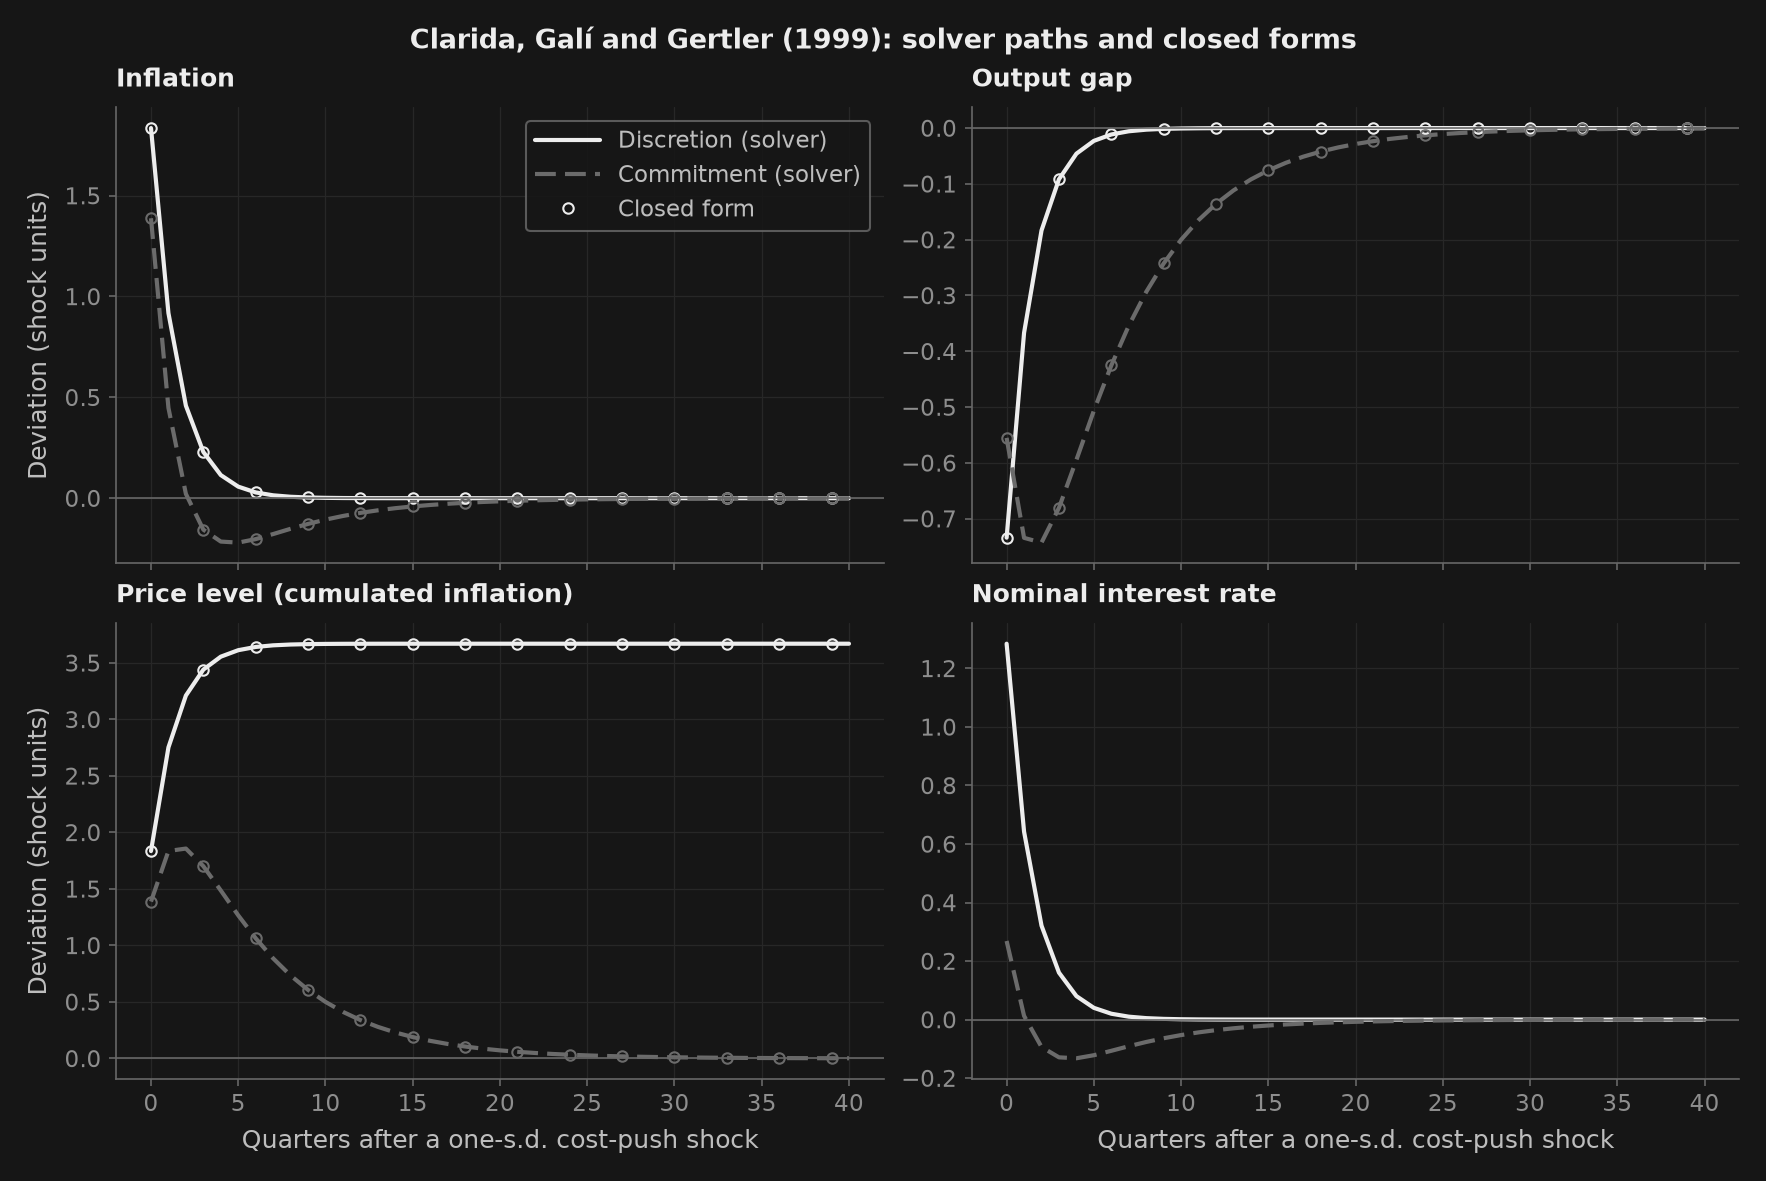

In [4]:
col, dash = _nbstyle.palette(2), _nbstyle.styles(2)
quarters = np.arange(H + 1)
fig, axes = _nbstyle.figura(2, 2, figsize=(11.5, 7.6), sharex=True)
panels = [("Inflation", pi_d, pi_c, paths["pi_disc"], paths["pi_comm"]),
          ("Output gap", x_d, x_c, paths["x_disc"], paths["x_comm"]),
          ("Price level (cumulated inflation)", price_d, price_c,
           np.cumsum(paths["pi_disc"]), np.cumsum(paths["pi_comm"])),
          ("Nominal interest rate", i_d, i_c, None, None)]
for ax, (title, sol_d, sol_c, form_d, form_c) in zip(axes.flat, panels):
    ax.plot(quarters, sol_d, color=col[0], linestyle=dash[0], lw=2.0, label="Discretion (solver)")
    ax.plot(quarters, sol_c, color=col[1], linestyle=dash[1], lw=2.0, label="Commitment (solver)")
    if form_d is not None:
        ax.plot(quarters[::3], form_d[::3], "o", color=col[0], mfc="none", ms=5, label="Closed form")
        ax.plot(quarters[::3], form_c[::3], "o", color=col[1], mfc="none", ms=5)
    ax.axhline(0.0, color=_nbstyle.SPINE, lw=0.8)
    ax.set_title(title)
for ax in axes[:, 0]:
    ax.set_ylabel("Deviation (shock units)")
for ax in axes[1]:
    ax.set_xlabel("Quarters after a one-s.d. cost-push shock")
axes[0, 0].legend(loc="upper right", frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
fig.suptitle("Clarida, Galí and Gertler (1999): solver paths and closed forms")

### 3. Commitment within a simple rule, and the optimal simple rule

CGG's simple-rule result says that committing to $x_t=-\omega u_t$ is equivalent to discretion by a central banker with output weight $\alpha(1-\beta\rho)$, so a discretionary solve with that weight must deliver $\omega^c$. `osr` searches instead over the coefficients of an instrument rule, $i_t=g_t/\varphi+\phi_\pi\pi_t+\phi_x x_t$, which offsets demand shocks and responds to inflation and the output gap. Every such rule implies $x_t\propto u_t$, so the best it can do is CGG's simple-rule loss. That optimum is a ridge rather than a point: all rules with $\varphi(\phi_\pi-\rho)=c_0(1-\rho+\varphi\phi_x)$, where $c_0=\omega^c(1-\beta\rho)/(1-\lambda\omega^c)$, implement the same allocation.

In [5]:
conservative = discretionary_policy(model, target_vars=["pi", "x"],
                                    weights={"pi": 1.0, "x": alpha * (1.0 - beta * rho)},
                                    instruments="i", beta=beta, tol=1e-12, max_iter=5000,
                                    compare_commitment=False)
x0_conservative = conservative.linear_model.irf("eps_u", horizon=1)["x"].iloc[0]
record("Simple rule: conservative central banker delivers -omega_c", abs(x0_conservative + cf["omega_c"]))

tracking = cgg_model(CALIB, rule="i = g/phi + phi_pi*pi + phi_x*x;")
best = osr(tracking, ["phi_pi", "phi_x"], weights, bounds={"phi_pi": (1.0, 10.0), "phi_x": (0.0, 10.0)})
x0_osr = best.optimal_model.irf("eps_u", horizon=1)["x"].iloc[0]
record("Simple rule: OSR loss = CGG simple-rule loss (relative)", abs(best.loss_opt / cf["loss_simple"] - 1.0), tol=1e-6)
record("Simple rule: OSR allocation x = -omega_c u (relative)", abs(x0_osr / cf["omega_c"] + 1.0), tol=1e-6)
c0 = cf["omega_c"] * (1.0 - beta * rho) / (1.0 - lam * cf["omega_c"])
phi_pi_ridge = rho + c0 * (1.0 - rho + phi * best.optimal_params["phi_x"]) / phi
print("OSR coefficients:", {k: round(v, 4) for k, v in best.optimal_params.items()},
      f"| ridge value of phi_pi at that phi_x: {phi_pi_ridge:.4f} | converged: {best.converged}")
print(f"omega_c = {cf['omega_c']:.4f} versus the discretionary response lambda*q = {lam * cf['q']:.4f}")
assert best.converged and abs(phi_pi_ridge - best.optimal_params["phi_pi"]) < 1e-3
assert all(c["max_error"] < c["tolerance"] for c in checks)

OSR coefficients: {'phi_pi': 1.3424, 'phi_x': 0.5635} | ridge value of phi_pi at that phi_x: 1.3424 | converged: True
omega_c = 1.3558 versus the discretionary response lambda*q = 0.7339


### 4. How large are the gains from commitment, and by which criterion?

The `loss` attribute of each result is the **unconditional** loss $E[\pi_t^2]+\alpha E[x_t^2]$, the average over the stationary distribution. The `conditional_loss` attribute is the planner's own criterion evaluated from the steady state, $(1-\beta)E_0\sum_t\beta^t(\pi_t^2+\alpha x_t^2)$. `stabilization_bias` compares unconditional losses by default and conditional ones with `loss_criterion="conditional"`. From the steady state the commitment solution is the fully optimal (Ramsey) policy, so it can never lose to discretion. Unconditionally it can: the timeless rule keeps honoring past promises, which is costly on average when the future is discounted heavily (Jensen and McCallum 2002). Both losses have closed forms here. Under commitment the responses are sums of two geometric sequences, $a\delta^j+b\rho^j$. The conditional losses are also checked against discounted sums of squared impulse responses. The left panel traces both regimes' variance frontiers as the output weight varies. The right panel recomputes the loss ratio at different discount factors.

In [6]:
def conditional_loss(linear_model, weights, beta, horizon=4000):
    """(1 - beta) E_0 sum_t beta^t (loss_t) from discounted squared responses to unit shocks."""
    discount = beta ** np.arange(horizon + 1)
    total = 0.0
    for shock in linear_model.shocks:
        irf = linear_model.irf(shock, horizon=horizon)
        total += sum(w * np.sum(discount * irf[v].to_numpy() ** 2) for v, w in weights.items())
    return total


def variances(linear_model):
    """Unconditional variances of inflation and the output gap."""
    with warnings.catch_warnings():
        # Multipliers on constraints that never bind (the IS curve, the demand process) have
        # zero variance, so their variance decompositions are undefined: expected here.
        warnings.filterwarnings("ignore", message="forecast-error variance is zero")
        cov = linear_model.theoretical_moments().covariance
    return cov.loc["pi", "pi"], cov.loc["x", "x"]


record("Losses: discretion, unconditional (relative)", abs(disc.loss / cf["loss_disc"] - 1.0))
record("Losses: commitment, unconditional (relative)", abs(comm.loss / cf["loss_comm"] - 1.0))
record("Losses: discretion, conditional (relative)", abs(disc.conditional_loss / cf["cond_disc"] - 1.0))
record("Losses: commitment, conditional (relative)", abs(comm.conditional_loss / cf["cond_comm"] - 1.0))
record("Losses: conditional_loss against discounted squared responses (relative)",
       max(abs(r.conditional_loss / conditional_loss(r.linear_model, weights, beta) - 1.0) for r in (disc, comm)))
solved = {"discretion": (disc.loss, disc.conditional_loss),
          "optimal simple rule (OSR)": (best.loss_opt, conditional_loss(best.optimal_model, weights, beta)),
          "timeless commitment": (comm.loss, comm.conditional_loss)}
table = pd.DataFrame({"unconditional (.loss)": {k: v[0] for k, v in solved.items()},
                      "conditional, from the steady state": {k: v[1] for k, v in solved.items()}})
print(table.round(4).to_string())
disc_conditional = discretionary_policy(model, ["pi", "x"], weights, "i", beta=beta, tol=1e-12, max_iter=5000,
                                        loss_criterion="conditional")
print(f"stabilization_bias: {disc.stabilization_bias:.4f} by default (unconditional), "
      f"{disc_conditional.stabilization_bias:.4f} with loss_criterion='conditional'")

frontier = []
for alpha_k in np.geomspace(0.02, 2.0, 15):
    res_k = discretionary_policy(model, ["pi", "x"], {"pi": 1.0, "x": alpha_k}, "i",
                                 beta=beta, tol=1e-12, max_iter=20000)
    for regime, lm in (("discretion", res_k.linear_model), ("commitment", res_k.commitment_result.linear_model)):
        var_pi, var_x = variances(lm)
        frontier.append({"alpha": alpha_k, "regime": regime, "var_pi": var_pi, "var_x": var_x})
frontier = pd.DataFrame(frontier)

ratios = []
for beta_k in (0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99, 0.995):
    res_k = discretionary_policy(cgg_model({**CALIB, "beta": beta_k}), ["pi", "x"], weights, "i",
                                 beta=beta_k, tol=1e-12, max_iter=50000)
    com_k = res_k.commitment_result
    ratios.append({"beta": beta_k, "converged": res_k.converged,
                   "unconditional": com_k.loss / res_k.loss,
                   "conditional": com_k.conditional_loss / res_k.conditional_loss})
ratios = pd.DataFrame(ratios)
print(ratios.round(4).to_string(index=False))
assert ratios["converged"].all() and (ratios["conditional"] < 1.0).all()
assert all(c["max_error"] < c["tolerance"] for c in checks)

                           unconditional (.loss)  conditional, from the steady state
discretion                                4.6685                              4.6530
optimal simple rule (OSR)                 4.5194                              4.5044
timeless commitment                       3.1554                              3.1112
stabilization_bias: 1.5132 by default (unconditional), 1.5418 with loss_criterion='conditional'


 beta  converged  unconditional  conditional
0.300       True         1.9139       0.9800
0.400       True         1.7462       0.9669
0.500       True         1.5741       0.9481
0.600       True         1.3967       0.9210
0.700       True         1.2137       0.8820
0.800       True         1.0262       0.8268
0.850       True         0.9319       0.7921
0.900       True         0.8383       0.7522
0.950       True         0.7468       0.7075
0.990       True         0.6759       0.6686
0.995       True         0.6672       0.6636


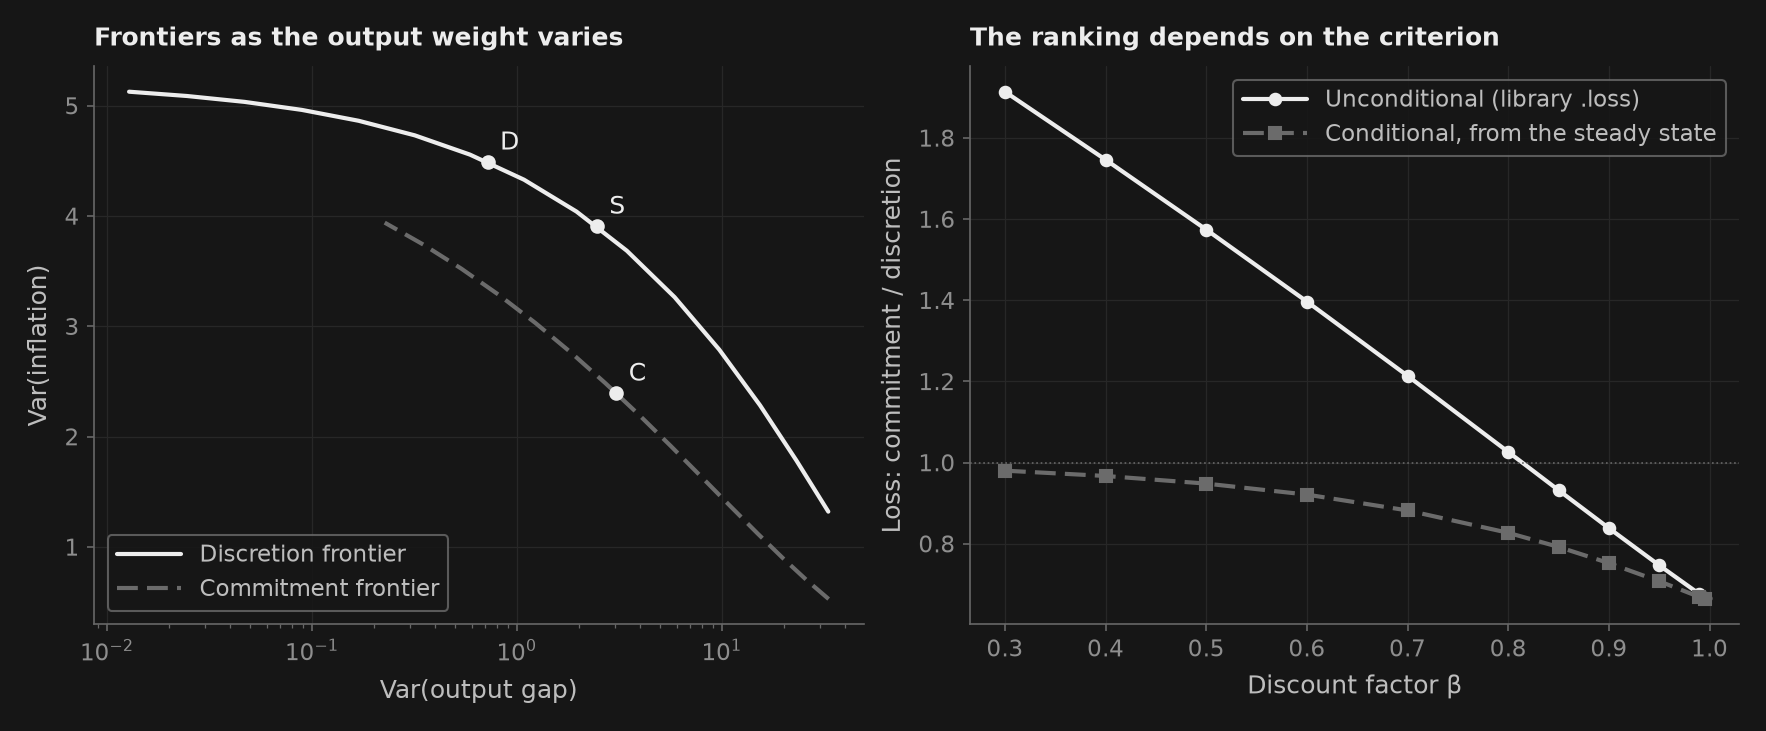

In [7]:
fig, (ax1, ax2) = _nbstyle.figura(1, 2, figsize=(11.5, 4.6))
for (regime, grp), color, ls in zip(frontier.groupby("regime", sort=False), col, dash):
    ax1.plot(grp["var_x"], grp["var_pi"], color=color, linestyle=ls, lw=2.0, label=f"{regime.capitalize()} frontier")
points = {"D": disc.linear_model, "S": best.optimal_model, "C": comm.linear_model}
for tag, lm in points.items():
    var_pi, var_x = variances(lm)
    ax1.plot(var_x, var_pi, "o", color=_nbstyle.TINTA, ms=6)
    ax1.annotate(tag, (var_x, var_pi), textcoords="offset points", xytext=(6, 6), color=_nbstyle.TINTA)
ax1.set(xscale="log", xlabel="Var(output gap)", ylabel="Var(inflation)",
        title="Frontiers as the output weight varies")
ax1.legend(loc="lower left", frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax2.plot(ratios["beta"], ratios["unconditional"], color=col[0], linestyle=dash[0], lw=2.0, marker="o",
         label="Unconditional (library .loss)")
ax2.plot(ratios["beta"], ratios["conditional"], color=col[1], linestyle=dash[1], lw=2.0, marker="s",
         label="Conditional, from the steady state")
ax2.axhline(1.0, color=_nbstyle.SPINE, lw=0.8, linestyle=":")
ax2.set(xlabel="Discount factor β", ylabel="Loss: commitment / discretion",
        title="The ranking depends on the criterion")
ax2.legend(loc="upper right", frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)

In the left panel, D, S and C mark discretion, the optimal simple rule and timeless commitment at the baseline weight. S lies on the discretion frontier because the simple rule reproduces discretion with a smaller output weight; only history-dependent commitment moves the frontier.

### 5. Robustness: the formulas hold away from the calibration

A replication that holds only at one calibration could be a coincidence. The loop below draws 25 random calibrations and compares the discretion and commitment paths, and both losses, with the closed forms, scaling each path error by the largest response.

In [8]:
rng = np.random.default_rng(1999)
worst_path, worst_loss = 0.0, 0.0
for draw in range(25):
    p = {"beta": rng.uniform(0.9, 0.995), "phi": rng.uniform(0.3, 2.0), "lam": rng.uniform(0.02, 0.5),
         "alpha": rng.uniform(0.02, 1.0), "rho": rng.uniform(0.0, 0.9), "mu": rng.uniform(0.0, 0.9)}
    res_k = discretionary_policy(cgg_model(p), ["pi", "x"], {"pi": 1.0, "x": p["alpha"]}, "i",
                                 beta=p["beta"], tol=1e-12, max_iter=20000)
    cf_k = cgg_closed_forms(**p)
    path_k = closed_form_paths(cf_k, p["rho"], p["alpha"], p["lam"], H)
    r_d = res_k.linear_model.irf("eps_u", horizon=H)
    r_c = res_k.commitment_result.linear_model.irf("eps_u", horizon=H)
    scale = max(1.0, max(np.max(np.abs(v)) for v in path_k.values()))
    worst_path = max(worst_path, np.max(np.abs(r_d["pi"].to_numpy() - path_k["pi_disc"])) / scale,
                     np.max(np.abs(r_d["x"].to_numpy() - path_k["x_disc"])) / scale,
                     np.max(np.abs(r_c["pi"].to_numpy() - path_k["pi_comm"])) / scale,
                     np.max(np.abs(r_c["x"].to_numpy() - path_k["x_comm"])) / scale)
    worst_loss = max(worst_loss, abs(res_k.loss / cf_k["loss_disc"] - 1.0),
                     abs(res_k.commitment_result.loss / cf_k["loss_comm"] - 1.0),
                     abs(res_k.conditional_loss / cf_k["cond_disc"] - 1.0),
                     abs(res_k.commitment_result.conditional_loss / cf_k["cond_comm"] - 1.0))
    assert res_k.converged
record("Robustness: 25 random calibrations, paths (relative)", worst_path)
record("Robustness: 25 random calibrations, both losses (relative)", worst_loss)
print(f"Largest relative path error: {worst_path:.1e}; largest relative loss error: {worst_loss:.1e}")
assert all(c["max_error"] < c["tolerance"] for c in checks)

Largest relative path error: 1.2e-12; largest relative loss error: 2.4e-12


### Replication scorecard

Every check above, with the error measured and the tolerance it had to meet. The verdict line is computed from the table.

In [9]:
scorecard = pd.DataFrame(checks)
scorecard["passed"] = scorecard["max_error"] < scorecard["tolerance"]
print(scorecard.to_string(index=False, formatters={"max_error": "{:.1e}".format, "tolerance": "{:.0e}".format}))
verdict = "reproduced" if scorecard["passed"].all() else "NOT reproduced"
print(f"\n{int(scorecard['passed'].sum())} of {len(scorecard)} checks pass: CGG (1999) results {verdict}.")
assert scorecard["passed"].all()

                                                                  result max_error tolerance  passed
                               Discretion: inflation path pi = alpha q u   1.0e-12     1e-09    True
                             Discretion: output-gap path x = -lambda q u   4.1e-13     1e-09    True
               Discretion: lean against the wind, x = -(lambda/alpha) pi   2.2e-16     1e-09    True
                          Discretion: implied rule i = gamma_pi E pi(+1)   3.4e-13     1e-09    True
                                   Discretion: demand shock fully offset   0.0e+00     1e-09    True
                           Discretion: the rate tracks demand, i = g/phi   0.0e+00     1e-09    True
                               Commitment: output-gap path (closed form)   4.3e-15     1e-09    True
                                Commitment: inflation path (closed form)   3.6e-15     1e-09    True
              Commitment: targeting rule pi = -(alpha/lambda)(x - x(-1))   1.6e-15     1e-0

## Read the output

Each closed-form comparison in the scorecard is at rounding level, far inside its tolerance, and it stays there at random calibrations. The two OSR rows are limited by the derivative-free search, which is why they carry a relative tolerance. So the four solvers reproduce CGG's discretion, simple-rule and commitment results as analytical statements, not just at one calibration. The two commitment routes (matrix Lagrangian and symbolic first-order conditions) agree with each other to rounding error. The symbolic conditions give the targeting rule once the zero IS-curve multiplier is dropped.

The hero figure shows the economics. After a cost-push shock the discretionary central bank splits the adjustment between inflation and the output gap, and the price level settles permanently higher. The committed central bank accepts a smaller initial output loss but keeps the gap negative for longer, and the price level returns towards its starting value. The interest-rate panel is a model outcome, not a policy recommendation: the commitment path of $i_t$ follows from the targeting rule and the IS curve.

Section 4 is the caveat. With the planner's criterion evaluated from the steady state, commitment beats discretion at every discount factor in the table. With the unconditional criterion, which `.loss` and the default `stabilization_bias` use, the ranking flips at low discount factors. A positive default `stabilization_bias` is therefore a property of the calibration, not a theorem. With `loss_criterion="conditional"` it is never negative. The frontier panel separates the two commitment ideas. The simple rule only moves along the discretion frontier. History dependence is what shifts it inwards.

## Your turn

Change the persistence of the cost-push shock or the discount factor and re-run the comparison. The assertion checks that the solvers still match the closed forms.

1. **Basic.** With the default `rho_custom = 0.0`, compare $\omega^c$ with the discretionary response $\lambda q$. Why does commitment to a simple rule gain nothing when cost-push shocks are serially uncorrelated, while the timeless commitment still lowers the loss?
2. **Intermediate.** Set `rho_custom = 0.9`. How do the loss gap and the conservative weight $\alpha(1-\beta\rho)$ change, and why does persistence make commitment more valuable?
3. **Stretch.** Keep `rho_custom = 0.0` and set `beta_custom = 0.5`. Is `stabilization_bias` still positive? Compare it with the bias under `loss_criterion="conditional"`, and use the conditional losses to explain why the fully optimal policy still wins from the steady state (Jensen and McCallum 2002).

In [10]:
rho_custom = 0.0    # ← change this: cost-push persistence, any value in [0, 0.95]
beta_custom = 0.99  # ← change this: discount factor, any value in [0.3, 0.995]
assert 0.0 <= rho_custom <= 0.95 and 0.3 <= beta_custom <= 0.995
custom = {**CALIB, "rho": rho_custom, "beta": beta_custom}
res_custom = discretionary_policy(cgg_model(custom), ["pi", "x"], weights, "i",
                                  beta=beta_custom, tol=1e-12, max_iter=50000)
cf_custom = cgg_closed_forms(**custom)
path_custom = closed_form_paths(cf_custom, rho_custom, alpha, lam, H)
err_custom = max(
    np.max(np.abs(res_custom.linear_model.irf("eps_u", horizon=H)["x"].to_numpy() - path_custom["x_disc"])),
    np.max(np.abs(res_custom.commitment_result.linear_model.irf("eps_u", horizon=H)["x"].to_numpy()
                  - path_custom["x_comm"])))
print(f"rho = {rho_custom}, beta = {beta_custom}: largest closed-form error {err_custom:.1e}")
print(f"omega_c = {cf_custom['omega_c']:.4f}; discretionary response lambda*q = {lam * cf_custom['q']:.4f}")
print(f"Unconditional loss: discretion {res_custom.loss:.4f}, timeless commitment "
      f"{res_custom.commitment_result.loss:.4f} (stabilization_bias {res_custom.stabilization_bias:+.4f})")
bias_conditional = res_custom.conditional_loss - res_custom.commitment_result.conditional_loss
print(f"Conditional loss from the steady state: discretion {res_custom.conditional_loss:.4f}, commitment "
      f"{res_custom.commitment_result.conditional_loss:.4f} (bias with loss_criterion='conditional' "
      f"{bias_conditional:+.4f})")
assert res_custom.converged and err_custom < TOL

rho = 0.0, beta = 0.99: largest closed-form error 1.1e-16
omega_c = 0.3846; discretionary response lambda*q = 0.3846
Unconditional loss: discretion 0.9615, timeless commitment 0.8264 (stabilization_bias +0.1352)
Conditional loss from the steady state: discretion 0.9615, commitment 0.8227 (bias with loss_criterion='conditional' +0.1389)


## How comprehensive is this?

Notebook 45 solves discretion and commitment with an inflation-bias target before moving on to DSGE-VAR and news shocks, and notebooks 41 and 57 add an occasionally binding zero lower bound. `discretionary_policy`, `lq_commitment` and `osr` are documented in `docs/dsge_phase_c.md`; all four solvers take models built with `build_dynare` or `load_mod`, so the same checks can be pointed at larger models. This notebook checks linear-quadratic policy in a three-equation model; it does not validate nonlinear Ramsey policy or welfare-based loss functions.